# Investigating Mouse Pancreas Atlas

## Load dataset

In [ ]:
import scanpy as sc
from utils.io import read_anndata

adata = read_anndata(
    'data/Hrovatin2023_preprocessed.zarr',
    X='X',
    obs='obs',
    var='var',
    obsm='obsm',
    # dask=True,
    # backed=True,
)
adata

dask: False, backed: False
Read slot "X", store as "X"...
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


AnnData object with n_obs × n_vars = 301796 × 31202
    obs: 'batch_integration', 'dataset', 'design', 'cell_cycle_phase', 'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering', 'strain', 'age', 'cell_type_originalDataset_unified', 'cell_type_originalDataset', 'cell_type_reannotatedIntegrated', 'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts', 'age_approxDays', 'dataset__design__sample', 'cell_subtype_immune_reannotatedIntegrated', 'cell_subtype_endothelial_reannotatedIntegrated', 'emptyDrops_LogProb_scaled', 'cell_subtype_beta_coarse_reannotatedIntegrated', 'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3', 'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11', 'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19', 'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'diabetes_model', 'chemical_stress', 'GEO

In [2]:
adata.var["gene_symbol"] = adata.var["feature_name"].str.split('_').str[0]

## Subset beta cells

Check which cell types exist in the dataset

In [3]:
adata.obs['cell_type_reannotatedIntegrated'].value_counts()


cell_type_reannotatedIntegrated
beta             102143
alpha             40935
immune            31703
E non-endo.       29177
delta             24775
stellate a.       18332
endothelial       13469
ductal             8742
E endo.            7748
gamma              6999
beta+delta         5104
stellate q.        4970
alpha+delta        1901
beta+gamma         1209
delta+gamma        1069
endo. prolif.       887
lowQ                853
alpha+beta          683
schwann             617
acinar              480
Name: count, dtype: int64

In [4]:
beta_subset = adata[
    adata.obs['cell_type_reannotatedIntegrated'] == 'beta'
].copy()

## Recompute kNN

In [ ]:
# sc.pp.neighbors(beta_subset, n_neighbors=15, use_rep='X_integrated_umap_beta')

In [5]:
beta_subset.obs.columns

Index(['batch_integration', 'dataset', 'design', 'cell_cycle_phase',
       'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering',
       'strain', 'age', 'cell_type_originalDataset_unified',
       'cell_type_originalDataset', 'cell_type_reannotatedIntegrated',
       'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts',
       'age_approxDays', 'dataset__design__sample',
       'cell_subtype_immune_reannotatedIntegrated',
       'cell_subtype_endothelial_reannotatedIntegrated',
       'emptyDrops_LogProb_scaled',
       'cell_subtype_beta_coarse_reannotatedIntegrated',
       'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3',
       'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11',
       'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19',
       'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27',
       'assay_ontology_term_id', 'cell_type_ontology_term_id',
       'development_stage_ontology_

show nested batch effect

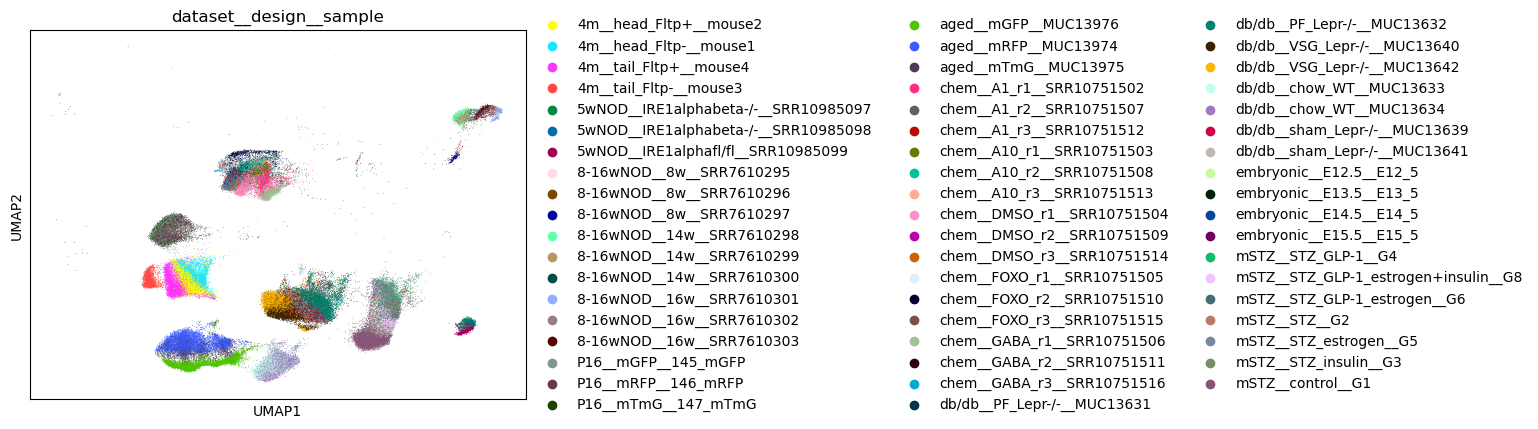

In [7]:
sc.pl.umap(beta_subset, color=['dataset__design__sample'], wspace=0.4)

In [ ]:
# sc.tl.umap(beta_subset)

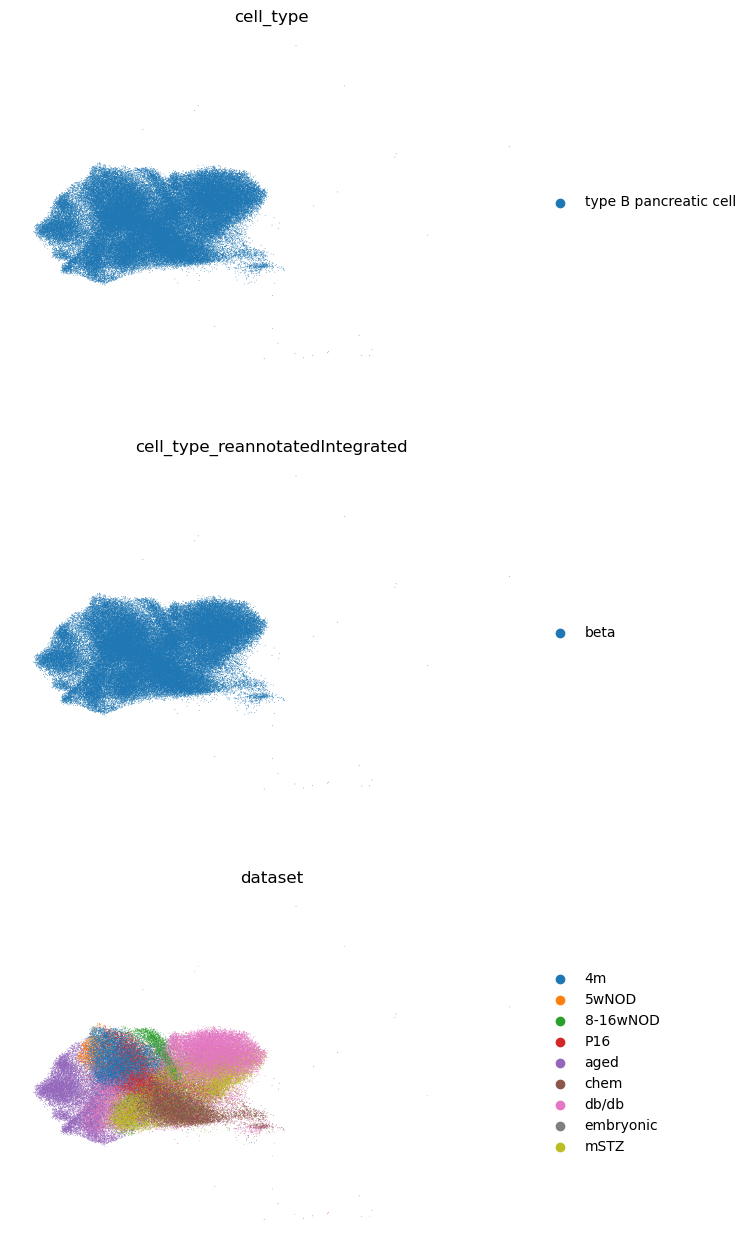

In [28]:
# sc.pl.umap(beta_subset, color='batch_integration')
sc.pl.embedding(
    beta_subset,
    'X_integrated_umap',
    color=['cell_type', 'cell_type_reannotatedIntegrated', 'dataset'],
    ncols=1,
    frameon=False,
)

You can see the successful batch integration here

### plot substates

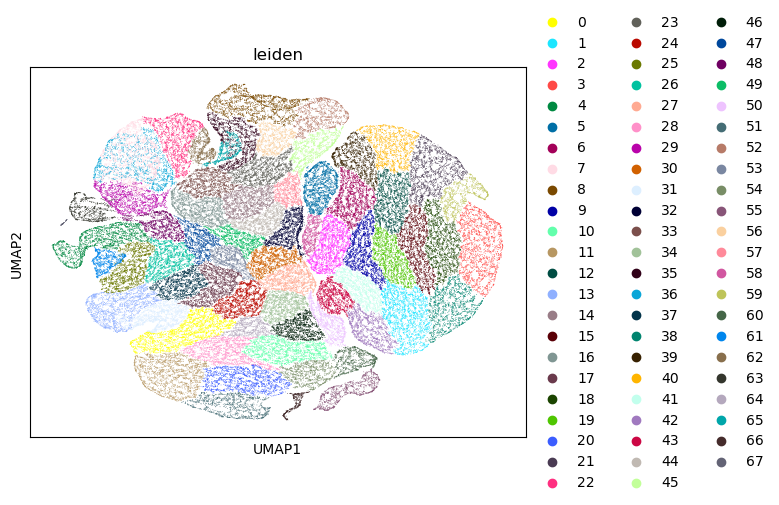

In [ ]:
# sc.tl.leiden(beta_subset, resolution=0.5)
# sc.pl.umap(beta_subset, color='leiden')

Cells with similar transcriptomes cluster together

## plot marker genes

In [21]:
marker_genes = ['Ppy', 'Ins2', 'Scg2', 'Iapp', 'Cltrn', 'Pcsk2', 'Chga']

In [14]:
print(beta_subset.var.columns)

Index(['present_Fltp_2y', 'present_Fltp_adult', 'present_Fltp_P16',
       'present_NOD', 'present_NOD_elimination', 'present_spikein_drug',
       'present_embryo', 'present_VSG', 'present_STZ', 'feature_is_filtered',
       'feature_name', 'feature_reference', 'feature_biotype',
       'feature_length', 'feature_type', 'highly_variable', 'means',
       'dispersions', 'dispersions_norm', 'highly_variable_nbatches',
       'highly_variable_intersection'],
      dtype='object')


In [32]:
beta_subset.var.head(10)

,present_Fltp_2y,present_Fltp_adult,present_Fltp_P16,present_NOD,present_NOD_elimination,present_spikein_drug,present_embryo,present_VSG,present_STZ,feature_is_filtered,...,feature_biotype,feature_length,feature_type,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,gene_symbol
ENSMUSG00000000001,True,True,True,True,True,True,True,True,True,False,...,gene,3262,protein_coding,False,0.353981,-0.367823,-0.297614,0,False,Gnai3
ENSMUSG00000000003,True,True,True,True,True,True,True,True,True,False,...,gene,799,protein_coding,False,0.000000,0.000000,0.000000,0,False,Pbsn
ENSMUSG00000000028,True,True,True,True,True,True,True,True,True,False,...,gene,1615,protein_coding,False,0.020844,-0.212117,-0.308203,0,False,Cdc45
ENSMUSG00000000031,True,True,True,True,True,True,True,True,True,False,...,gene,2306,lncRNA,True,0.125696,0.285979,1.315642,4,False,H19
ENSMUSG00000000037,True,True,True,True,True,True,True,True,True,False,...,gene,2953,protein_coding,False,0.002683,-0.250343,-0.322957,0,False,Scml2
ENSMUSG00000000049,True,True,True,True,True,True,True,True,True,False,...,gene,552,protein_coding,False,0.001903,-0.059964,0.308525,1,False,Apoh
ENSMUSG00000000056,True,True,True,True,True,True,True,True,True,False,...,gene,525,protein_coding,False,0.039003,-0.077908,0.069090,0,False,Narf
ENSMUSG00000000058,True,True,True,True,True,True,True,True,True,False,...,gene,974,protein_coding,False,0.071876,0.045076,0.606495,2,False,Cav2
ENSMUSG00000000078,True,True,True,True,True,True,True,True,True,False,...,gene,1115,protein_coding,True,0.401908,0.042906,2.210011,7,False,Klf6
ENSMUSG00000000085,True,True,True,True,True,True,True,True,True,False,...,gene,1334,protein_coding,False,0.150468,-0.199014,-0.090049,0,False,Scmh1


I can see that the feature name is gene symbol _ some ID, so I try to map the gene symbol to the ID

In [ ]:
import pandas as pd

adata.var["gene_symbol"] = adata.var["feature_name"].str.split('_').str[0]

In [ ]:
marker_genes = ['Ins', 'Scg5', 'Pcsk1n', 'Ttr', 'Gnas', 'Ptprn', 'Cpe']

symbol_to_ID = {
    row['feature_name'].split('_')[0]: idx
    for idx, row in beta_subset.var.iterrows()
}

valid_genes = [symbol_to_ID[gene] for gene in marker_genes if gene in symbol_to_ID]

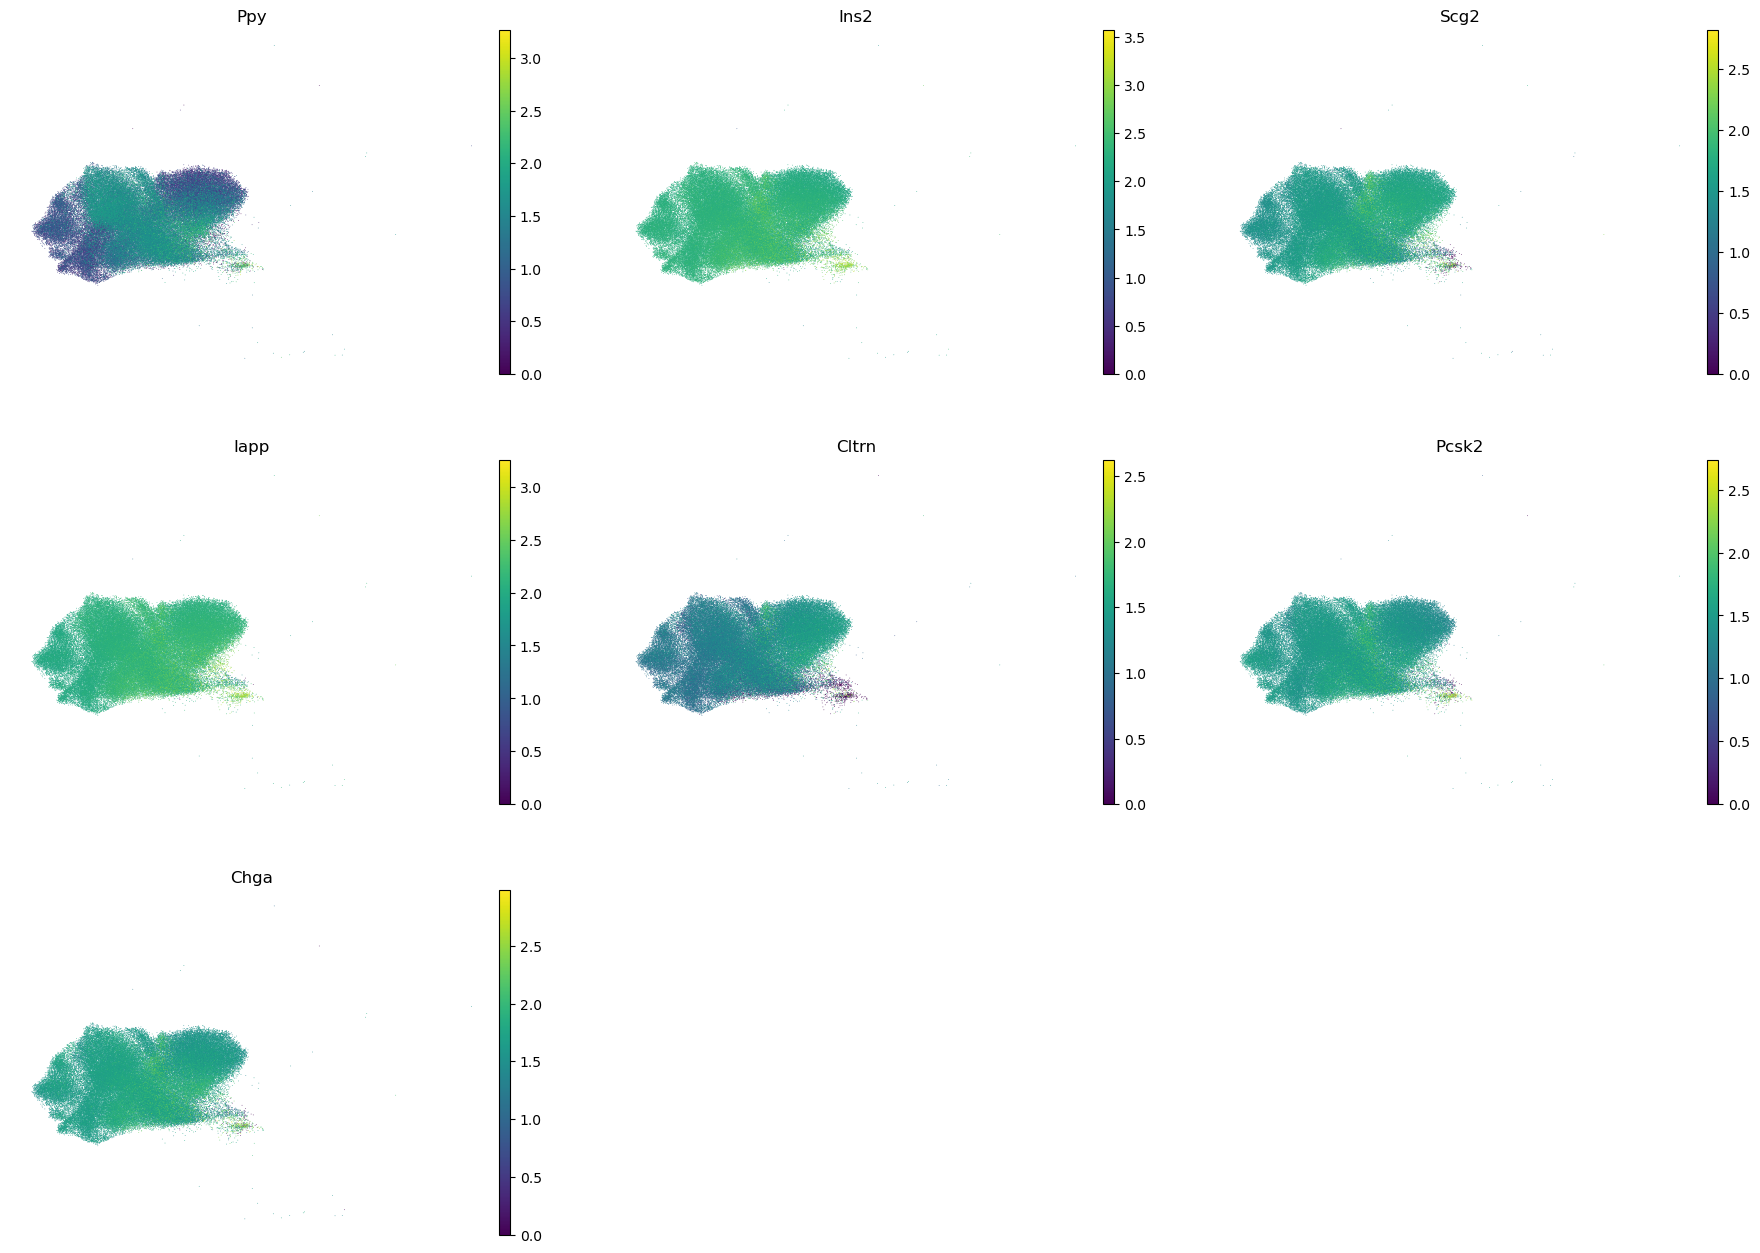

In [ ]:
# sc.pl.umap(beta_subset, color=marker_genes, cmap='viridis', size=20, gene_symbols='gene_symbol')
sc.pl.embedding(
    beta_subset,
    'X_integrated_umap',
    color=marker_genes,
    ncols=3,
    frameon=False,
    gene_symbols='gene_symbol'
)

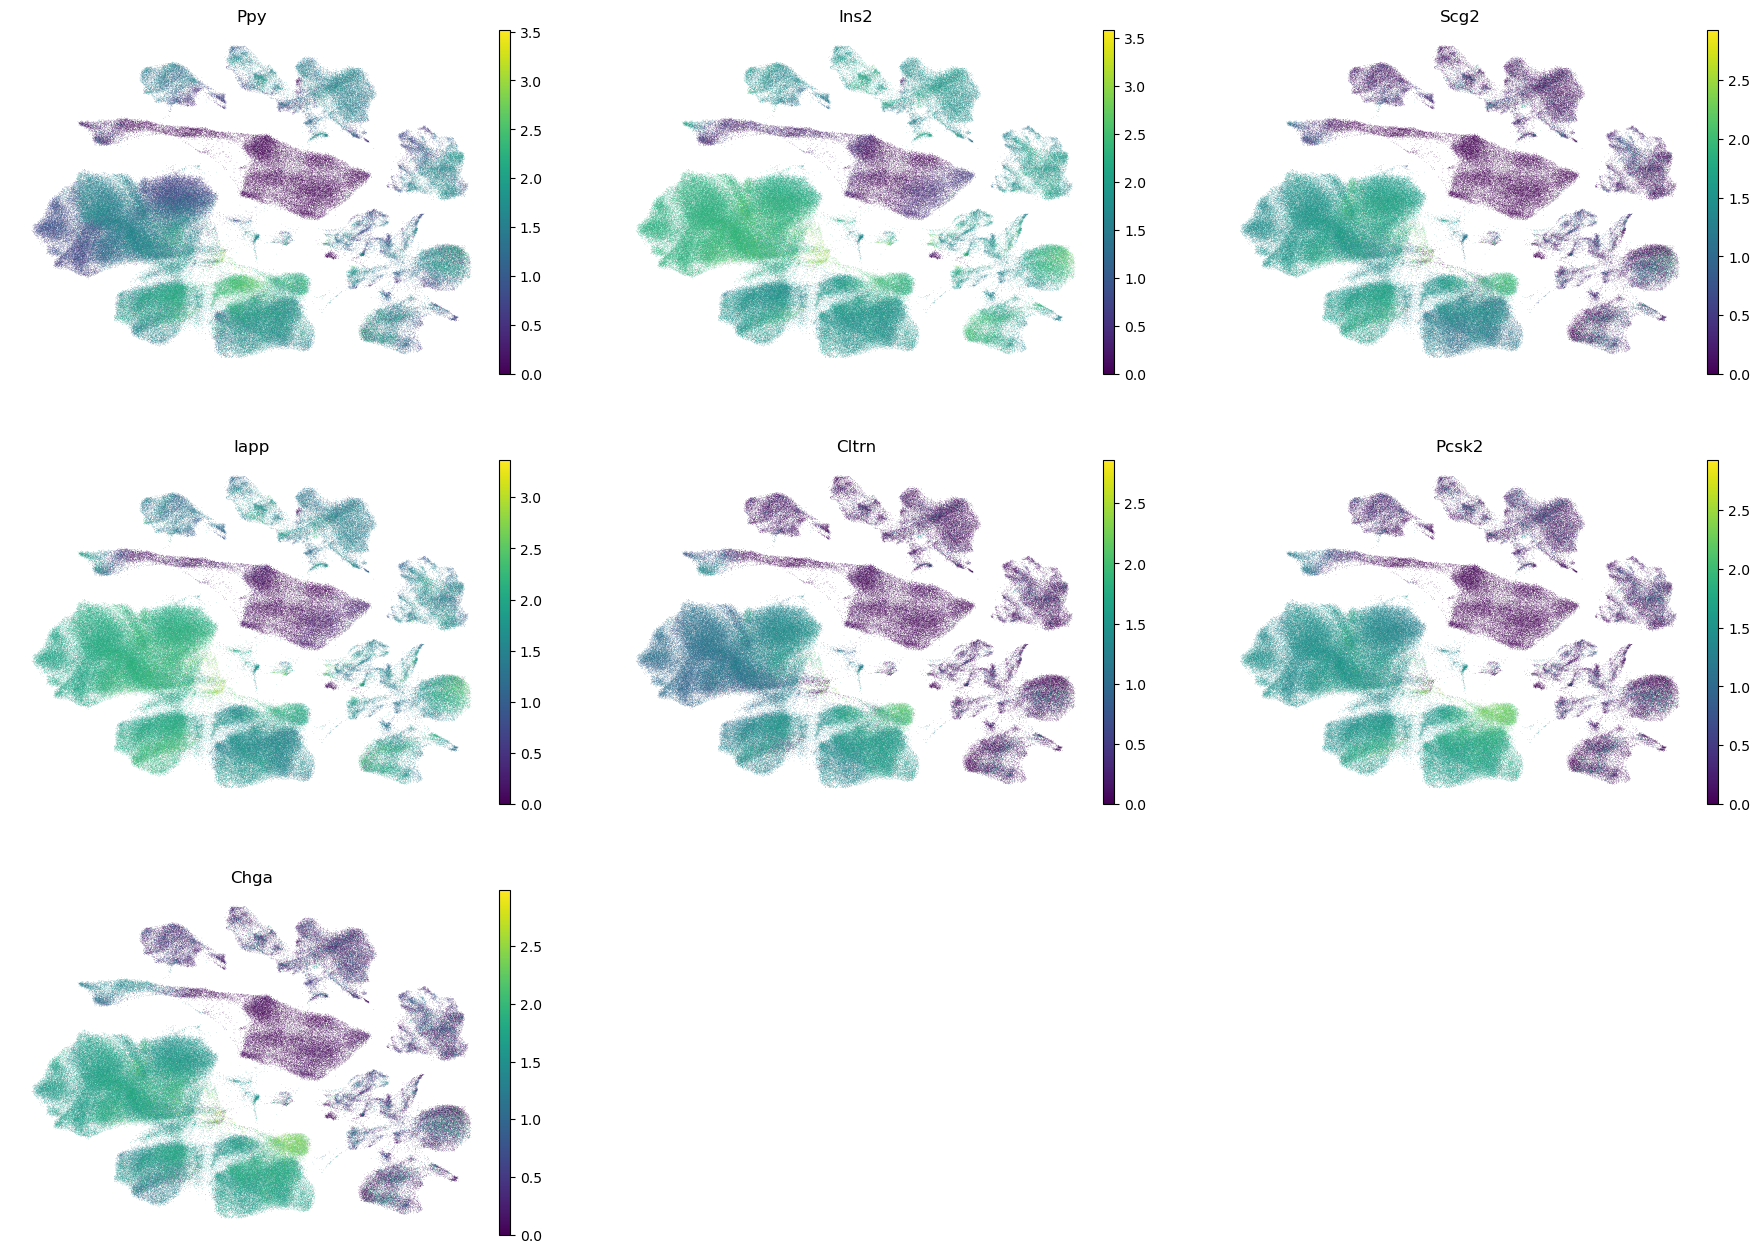

In [47]:
sc.pl.embedding(
    adata,
    'X_integrated_umap',
    color=marker_genes,
    ncols=3,
    frameon=False,
    gene_symbols='gene_symbol'
)

### against cell type

In [ ]:
print(beta_subset.obs.columns)

Index(['batch_integration', 'dataset', 'design', 'cell_cycle_phase',
       'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering',
       'strain', 'age', 'cell_type_originalDataset_unified',
       'cell_type_originalDataset', 'cell_type_reannotatedIntegrated',
       'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts',
       'age_approxDays', 'dataset__design__sample',
       'cell_subtype_immune_reannotatedIntegrated',
       'cell_subtype_endothelial_reannotatedIntegrated',
       'emptyDrops_LogProb_scaled',
       'cell_subtype_beta_coarse_reannotatedIntegrated',
       'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3',
       'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11',
       'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19',
       'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27',
       'assay_ontology_term_id', 'cell_type_ontology_term_id',
       'development_stage_ontology_

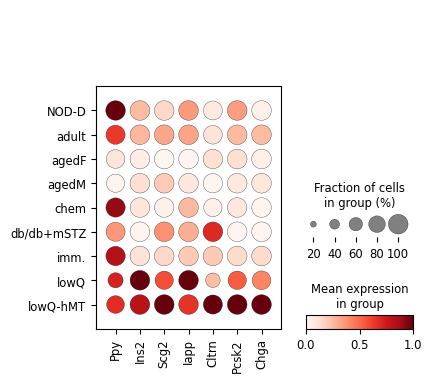

In [51]:
sc.pl.dotplot(beta_subset, marker_genes, groupby='cell_subtype_beta_coarse_reannotatedIntegrated', standard_scale='var', gene_symbols='gene_symbol')

It doesn't really mean anything..